In [1]:

# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import spacy

from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.feature_extraction.text import CountVectorizer

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel, Phrases
from gensim.models.phrases import Phraser
from gensim.corpora import Dictionary
from gensim.parsing.preprocessing import STOPWORDS

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer


import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# LOAD DATA

print("Loading 20 Newsgroups dataset")

newsgroups = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))
documents = newsgroups.data
true_labels = newsgroups.target

print(f"Total documents: {len(documents)}")


# FILTER SHORT DOCUMENTS

min_length = 50
filtered_docs = []
filtered_labels = []

for doc, label in zip(documents, true_labels):
    if len(doc.split()) > min_length:
        filtered_docs.append(doc)
        filtered_labels.append(label)

print(f"Documents after filtering: {len(filtered_docs)}")


# PREPROCESSING
print("Running preprocessing")

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

custom_stopwords = STOPWORDS.union({
    "edu", "com", "subject", "writes",
    "organization", "article", "lines",
    "would", "could", "also", "one",
    "get", "like", "know", "think"
})

def clean_text(doc):
    doc = doc.lower()

    # Remove emails & URLs
    doc = re.sub(r'\S+@\S+', ' ', doc)
    doc = re.sub(r'http\S+|www\S+', ' ', doc)

    # Remove alphanumeric junk
    doc = re.sub(r'\b[a-z]*\d+[a-z\d]*\b', ' ', doc)

    # Keep letters only
    doc = re.sub(r'[^a-z\s]', ' ', doc)

    doc = re.sub(r'\s+', ' ', doc)

    return doc.strip()


# Clean raw text
cleaned_docs = [clean_text(doc) for doc in filtered_docs]


# Lemmatization + POS filtering (keep nouns, verbs, adjectives)
processed_docs = []
for doc in nlp.pipe(cleaned_docs, batch_size=500):
    tokens = [
        token.lemma_
        for token in doc
        if token.pos_ in ["NOUN", "VERB", "ADJ"]
        and token.lemma_ not in custom_stopwords
        and len(token.lemma_) > 3
    ]
    processed_docs.append(tokens)

# ADD BIGRAMS

bigram = Phrases(processed_docs, min_count=10, threshold=100)
bigram_mod = Phraser(bigram)

processed_docs = [bigram_mod[doc] for doc in processed_docs]

# CREATE DICTIONARY & CORPUS

dictionary = corpora.Dictionary(processed_docs)

# Remove rare and frequent words
dictionary.filter_extremes(no_below=10, no_above=0.4)

corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

print(f"Vocabulary size: {len(dictionary)}")

# TRAIN LDA 

print("\nTraining LDA")

num_topics = 15

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=20,
    alpha='auto',
    eta='auto'
)

# TRAIN BERTopic

print("\nTraining BERTopic")

sentence_model = SentenceTransformer("all-MiniLM-L6-v2")

vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=10,
    token_pattern=r'(?u)\b[a-zA-Z]{4,}\b'
)

bertopic_model = BERTopic(
    embedding_model=sentence_model,
    vectorizer_model=vectorizer_model,
    nr_topics=16,
    min_topic_size=20,
    verbose=True
)

bertopic_topics, _ = bertopic_model.fit_transform(cleaned_docs)

# PRINT TOP WORDS

print("LDA TOPICS")


for i in range(num_topics):
    words = [word for word, _ in lda_model.show_topic(i, topn=10)]
    print(f"Topic {i}: {', '.join(words)}")



print("BERTopic TOPICS")


topic_info = bertopic_model.get_topic_info()
valid_topic_ids = topic_info[topic_info.Topic != -1]["Topic"].tolist()

for topic_id in valid_topic_ids:
    topic = bertopic_model.get_topic(topic_id)
    if topic:
        words = [word for word, _ in topic[:10]]
        print(f"Topic {topic_id}: {', '.join(words)}")


# COHERENCE

lda_coherence_model = CoherenceModel(
    model=lda_model,
    texts=processed_docs,
    dictionary=dictionary,
    coherence='c_v'
)
lda_coherence = lda_coherence_model.get_coherence()


# BERTopic Coherence
coherence_dictionary = Dictionary(processed_docs)

bertopic_topics_words = []

for topic_id in valid_topic_ids:
    topic = bertopic_model.get_topic(topic_id)
    if topic:
        words = [
            word for word, _ in topic
            if word in coherence_dictionary.token2id
        ][:10]
        if len(words) > 1:
            bertopic_topics_words.append(words)

bertopic_coherence_model = CoherenceModel(
    topics=bertopic_topics_words,
    texts=processed_docs,
    dictionary=coherence_dictionary,
    coherence='c_v'
)

bertopic_coherence = bertopic_coherence_model.get_coherence()

# TOPIC DIVERSITY

def topic_diversity(topics):
    unique_words = set()
    total_words = 0
    for topic in topics:
        unique_words.update(topic)
        total_words += len(topic)
    return len(unique_words) / total_words


lda_topics_words = [
    [word for word, _ in lda_model.show_topic(i, topn=10)]
    for i in range(num_topics)
]

lda_diversity = topic_diversity(lda_topics_words)
bertopic_diversity = topic_diversity(bertopic_topics_words)

# TOPIC OVERLAP

def compute_overlap(topics):
    n = len(topics)
    matrix = np.zeros((n, n))
    similarities = []

    for i in range(n):
        for j in range(n):
            set_i = set(topics[i])
            set_j = set(topics[j])
            intersection = len(set_i & set_j)
            union = len(set_i | set_j)
            score = intersection / union if union > 0 else 0
            matrix[i, j] = score
            if i != j:
                similarities.append(score)

    avg_similarity = np.mean(similarities)
    distinctiveness = 1 - avg_similarity

    return matrix, avg_similarity, distinctiveness


lda_overlap, lda_avg_similarity, lda_distinctiveness = compute_overlap(lda_topics_words)
bertopic_overlap, bertopic_avg_similarity, bertopic_distinctiveness = compute_overlap(bertopic_topics_words)

# ARI, NMI

lda_doc_topics = []
for bow in corpus:
    topic_probs = lda_model.get_document_topics(bow)
    dominant_topic = max(topic_probs, key=lambda x: x[1])[0]
    lda_doc_topics.append(dominant_topic)

valid_indices = [i for i, t in enumerate(bertopic_topics) if t != -1]

valid_true = [filtered_labels[i] for i in valid_indices]
valid_lda = [lda_doc_topics[i] for i in valid_indices]
valid_bertopic = [bertopic_topics[i] for i in valid_indices]

lda_ari = adjusted_rand_score(valid_true, valid_lda)
lda_nmi = normalized_mutual_info_score(valid_true, valid_lda)

bertopic_ari = adjusted_rand_score(valid_true, valid_bertopic)
bertopic_nmi = normalized_mutual_info_score(valid_true, valid_bertopic)

# RESULTS SUMMARY

print("\nFINAL RESULTS")

results = pd.DataFrame({
    "Metric": [
        "Coherence (C_v)",
        "Topic Diversity",
        "Topic Distinctiveness",
        "Average Jaccard Similarity",
        "Adjusted Rand Index (ARI)",
        "Normalized Mutual Information (NMI)"
    ],
    "LDA": [
        lda_coherence,
        lda_diversity,
        lda_distinctiveness,
        lda_avg_similarity,
        lda_ari,
        lda_nmi
    ],
    "BERTopic": [
        bertopic_coherence,
        bertopic_diversity,
        bertopic_distinctiveness,
        bertopic_avg_similarity,
        bertopic_ari,
        bertopic_nmi
    ]
})

print(results)




Loading 20 Newsgroups dataset
Total documents: 11314
Documents after filtering: 7647
Running preprocessing
Vocabulary size: 5291

Training LDA

Training BERTopic


2026-02-22 22:28:12,591 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/239 [00:00<?, ?it/s]

2026-02-22 22:35:30,053 - BERTopic - Embedding - Completed ✓
2026-02-22 22:35:30,055 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-22 22:35:58,177 - BERTopic - Dimensionality - Completed ✓
2026-02-22 22:35:58,177 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-22 22:35:58,506 - BERTopic - Cluster - Completed ✓
2026-02-22 22:35:58,506 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-02-22 22:36:00,061 - BERTopic - Representation - Completed ✓
2026-02-22 22:36:00,066 - BERTopic - Topic reduction - Reducing number of topics
2026-02-22 22:36:00,362 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-22 22:36:03,409 - BERTopic - Representation - Completed ✓
2026-02-22 22:36:03,411 - BERTopic - Topic reduction - Reduced number of topics from 35 to 16


LDA TOPICS
Topic 0: study, drug, child, disease, patient, report, number, year, case, health
Topic 1: space, launch, satellite, earth, mission, orbit, design, datum, moon, rocket
Topic 2: drive, card, work, need, problem, power, driver, good, speed, price
Topic 3: encryption, chip, government, security, privacy, public, message, encrypt, technology, secure
Topic 4: people, armenian, kill, child, turkish, israeli, attack, jewish, government, greek
Topic 5: believe, people, christian, thing, word, mean, life, religion, church, point
Topic 6: include, available, information, file, software, mail, image, version, program, user
Topic 7: post, book, people, read, question, group, good, want, time, answer
Topic 8: game, team, play, year, player, good, season, hockey, point, score
Topic 9: time, come, thing, look, good, tell, want, people, start, year
Topic 10: image, widget, color, code, value, line, point, function, time, write
Topic 11: right, state, people, government, weapon, control, fir

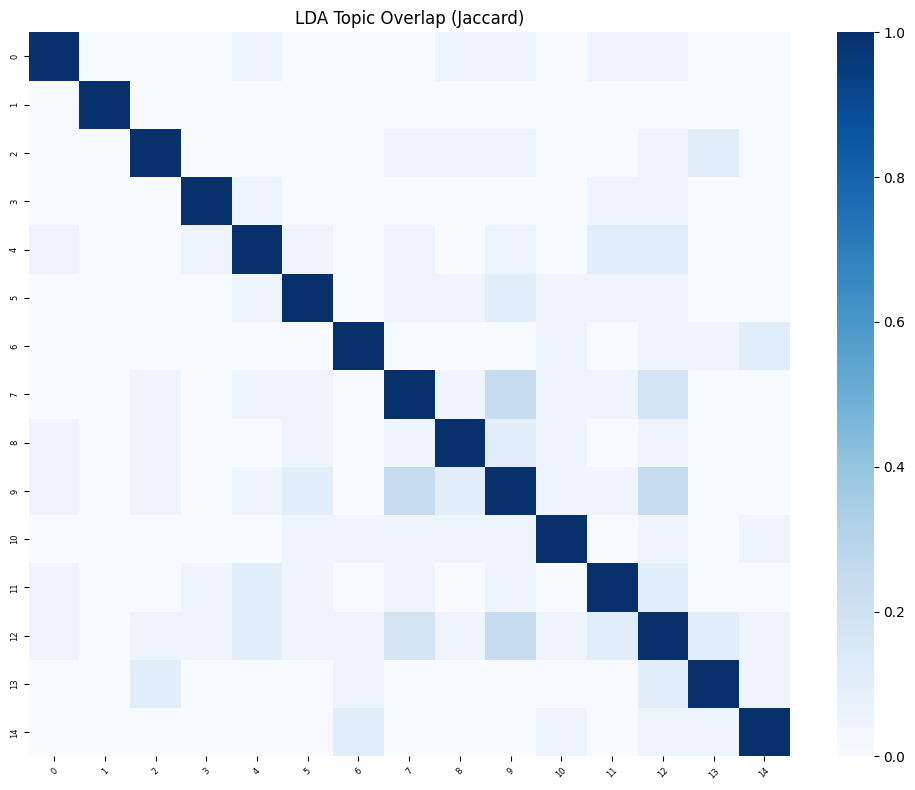

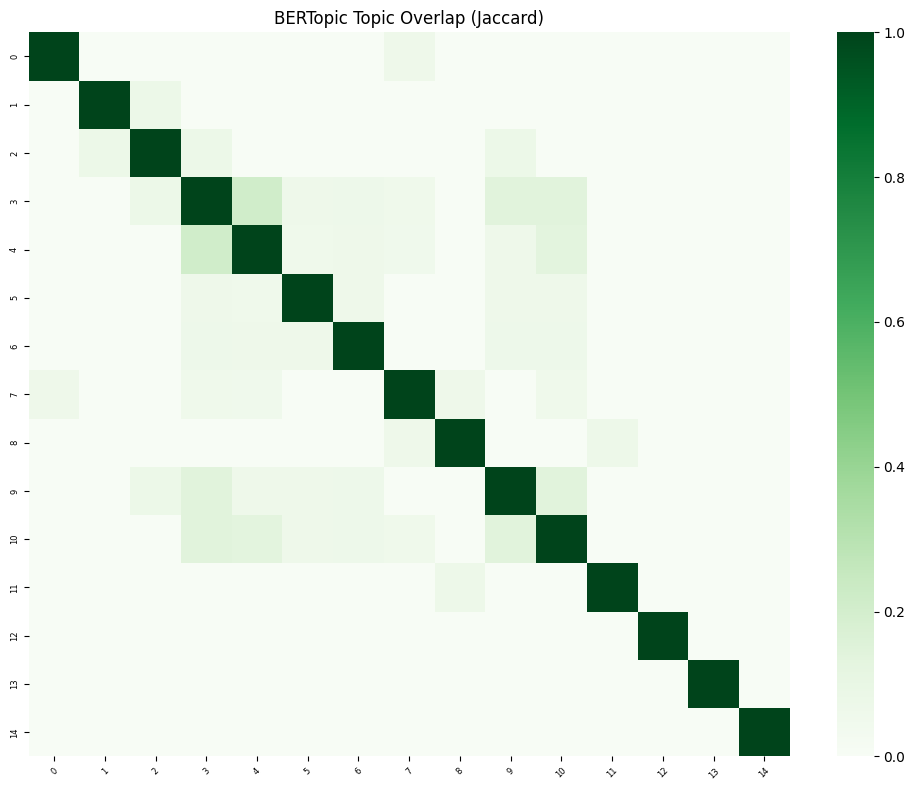


BERTopic interactive visualization



Top 10 topics bar chart - BERTOPIC


In [2]:

# HEATMAP VISUALIZATION

plt.figure(figsize=(10, 8))
sns.heatmap(lda_overlap, cmap="Blues")
plt.title("LDA Topic Overlap (Jaccard)")
plt.xticks(fontsize=6, rotation=45)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(bertopic_overlap, cmap="Greens")
plt.title("BERTopic Topic Overlap (Jaccard)")
plt.xticks(fontsize=6, rotation=45)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()


# BERTopic INTERACTIVE VISUALIZATION

print("\nBERTopic interactive visualization")
fig = bertopic_model.visualize_topics()
fig.show()

print("\nTop 10 topics bar chart - BERTOPIC")
# Top 10 topics bar chart - BERTOPIC
fig_bar = bertopic_model.visualize_barchart(top_n_topics=10)
fig_bar.show()


